# DLSD travel time — routes 146 & 147

Express segment on DuSable Lake Shore Drive (DLSD).

Side-quest analysis: Lake Shore Drive express segment timing by time of day.

## How to run

1. Set `CTA_API_KEY` in the repo-root [`.env`](../.env) (see [`.env.example`](../.env.example)).
2. From the repo root, start Jupyter and open this file:
   ```bash
   env/bin/jupyter lab notebooks/dlsd_travel_time_146_147.ipynb
   ```
3. **Run All** top-to-bottom through §6 (or through §2 only for stop discovery).

## Workflow

| Step | Source | Purpose |
|------|--------|---------|
| §1 | Mansueto | Trip counts per PID |
| §2 | Bus Tracker API | DLSD boundaries per PID |
| §3 | Mansueto | Per-run `dlsd_minutes` |
| §4–§5 | `dlsd_runs` | Duration and speed by time of day |
| §6 | Summary stats | Rush vs off-peak numbers |

Requires network access to CloudFront and `ctabustracker.com`.

In [1]:
%matplotlib inline

from __future__ import annotations

import json
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd() if (Path.cwd() / ".env").is_file() else Path.cwd().parent
_nb = REPO_ROOT / "notebooks"
if str(_nb) not in sys.path:
    sys.path.insert(0, str(_nb))

from cta_api import (
    LAST_CTA_REQUEST_URL,
    RT_TO_PID_URL,
    batch_pattern_stops,
    cta_api_get,
    load_dotenv,
    parquet_http_status,
    parquet_url,
    pattern_records,
    pattern_stops_from_ptr,
)

ROUTES = ["146", "147"]

load_dotenv()
if not os.environ.get("CTA_API_KEY"):
    raise RuntimeError("Set CTA_API_KEY in .env at the repo root")

_style_path = REPO_ROOT / "notebooks" / "cta_analysis.mplstyle"
if _style_path.is_file():
    plt.style.use(_style_path)

ROUTE_COLORS = {"146": "#9D8AB8", "147": "#4E79A7"}


def pattern_stops_ordered(pid: str) -> tuple[str, pd.DataFrame]:
    ptr_list = pattern_records(pid)
    if not ptr_list:
        raise RuntimeError(f"No pattern returned for PID {pid}")
    return pattern_stops_from_ptr(ptr_list[0])


def route_stops(rt: str, direction: str) -> pd.DataFrame:
    root = cta_api_get("getstops", rt=rt, dir=direction)
    stops = root.get("stops", [])
    if not stops:
        stop_el = root.get("stop", [])
        if isinstance(stop_el, dict):
            stop_el = [stop_el]
        stops = stop_el
    rows = [
        {
            "stpid": str(s["stpid"]),
            "stpnm": s["stpnm"],
            "lat": float(s["lat"]),
            "lon": float(s["lon"]),
        }
        for s in stops
    ]
    return pd.DataFrame(rows)


def haversine_feet(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    r_ft = 20902231  # Earth radius in feet
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dlon / 2) ** 2
    return 2 * r_ft * math.asin(math.sqrt(a))


def largest_hop_between_stops(stops: pd.DataFrame) -> pd.Series | None:
    if len(stops) < 2:
        return None
    hops = []
    for i in range(len(stops) - 1):
        a, b = stops.iloc[i], stops.iloc[i + 1]
        hops.append(
            {
                "entry_stpid": a["stpid"],
                "exit_stpid": b["stpid"],
                "entry_stpnm": a["stpnm"],
                "exit_stpnm": b["stpnm"],
                "hop_feet": haversine_feet(a["lat"], a["lon"], b["lat"], b["lon"]),
                "pdist_gap_ft": b["pdist_ft"] - a["pdist_ft"] if "pdist_ft" in stops.columns else np.nan,
            }
        )
    hop_df = pd.DataFrame(hops)
    return hop_df.loc[hop_df["hop_feet"].idxmax()]

## 1. PID discovery and volume

Pick the dominant PID per route (most trips among parquets with HTTP 200).

In [2]:
rt_df = pd.read_csv(RT_TO_PID_URL)
rt_df["rt"] = rt_df["rt"].astype(str)
rt_df["pid"] = rt_df["pid"].astype(str)

route_pids = {route: rt_df.loc[rt_df["rt"] == route, "pid"].tolist() for route in ROUTES}

volume_rows = []
for route in ROUTES:
    for pid in route_pids[route]:
        status = parquet_http_status(pid)
        if status != 200:
            volume_rows.append(
                {"route": route, "pid": pid, "trips": pd.NA, "http_status": status, "note": "missing on CloudFront"}
            )
            continue
        df = pd.read_parquet(parquet_url(pid), columns=["unique_trip_vehicle_day"])
        volume_rows.append(
            {
                "route": route,
                "pid": pid,
                "trips": df["unique_trip_vehicle_day"].nunique(),
                "http_status": 200,
                "note": None,
            }
        )
        del df

volume_df = pd.DataFrame(volume_rows)
volume_df

,route,pid,trips,http_status,note
0,146,7445,4241,200,NaN
1,146,7449,22676,200,NaN
2,146,6400,7364,200,NaN
3,146,6581,6608,200,NaN
4,146,6582,89272,200,NaN
5,146,7451,88094,200,NaN
6,146,7446,468,200,NaN
7,146,21482,<NA>,404,missing on CloudFront
8,146,7447,4145,200,NaN
9,146,6395,20683,200,NaN


In [3]:
available = volume_df[volume_df["http_status"] == 200].copy()
dominant_pid_by_route = (
    available.sort_values("trips", ascending=False).groupby("route", as_index=False).first()[
        ["route", "pid", "trips"]
    ]
)
dominant_pid_by_route

,route,pid,trips
0,146,6582,89272
1,147,4524,105314


## 2. Stop geography (CTA Bus Tracker API)

1. **`getpatterns`** for **all available PIDs** (batched, 10 per call) → `rtdir` + ordered pattern stops per PID.
2. Classify each PID: largest stop-to-stop hop above threshold → DLSD entry/exit; otherwise short-turn / no DLSD.
3. **`getstops`** (optional) with `rt` + `rtdir` for full route/direction stop list — map context for dominant PID.

### 2a. `getpatterns` — all available PIDs per route

In [4]:
all_pattern_stops: dict[str, tuple[str, pd.DataFrame]] = {}
pattern_meta_rows = []

for route in ROUTES:
    pids = available.loc[available["route"] == route, "pid"].tolist()
    batch = batch_pattern_stops(pids)
    all_pattern_stops.update(batch)
    for pid, (rtdir, stops) in batch.items():
        pattern_meta_rows.append(
            {"route": route, "pid": pid, "rtdir": rtdir, "pattern_stops": len(stops)}
        )

pattern_meta_df = pd.DataFrame(pattern_meta_rows).sort_values(["route", "pid"])
pattern_meta_df

  Skipped 4 PIDs not in live API: ['7446', '7447', '19397', '13245']
  Skipped 4 PIDs not in live API: ['4525', '4521', '4519', '7533']


,route,pid,rtdir,pattern_stops
12,146,6394,Northbound,31
6,146,6395,Northbound,39
10,146,6398,Northbound,18
7,146,6399,Northbound,37
2,146,6400,Northbound,41
3,146,6581,Northbound,50
4,146,6582,Northbound,51
13,146,6586,Northbound,46
0,146,7445,Southbound,41
11,146,7448,Southbound,29


### 2a.2 Classify PIDs — DLSD vs non-DLSD

Largest hop between consecutive pattern stops; hops above **10,000 ft** (~1.9 mi) are treated as the express DLSD segment.

In [5]:
DLSD_HOP_THRESHOLD_FT = 10_000

dlsd_boundary_rows = []
hop_summary_rows = []

for pid, (rtdir, stops) in all_pattern_stops.items():
    route = available.loc[available["pid"] == pid, "route"].iloc[0]
    hop = largest_hop_between_stops(stops)
    max_hop = float(hop["hop_feet"]) if hop is not None else np.nan
    hop_summary_rows.append(
        {
            "route": route,
            "pid": pid,
            "rtdir": rtdir,
            "max_hop_feet": max_hop,
            "uses_dlsd": hop is not None and max_hop > DLSD_HOP_THRESHOLD_FT,
        }
    )
    if hop is not None and max_hop > DLSD_HOP_THRESHOLD_FT:
        dlsd_boundary_rows.append({"route": route, "pid": pid, "rtdir": rtdir, **hop.to_dict()})

hop_summary_df = pd.DataFrame(hop_summary_rows).merge(
    available[["route", "pid", "trips"]], on=["route", "pid"], how="left"
)
dlsd_all_df = pd.DataFrame(dlsd_boundary_rows).merge(
    available[["route", "pid", "trips"]], on=["route", "pid"], how="left"
)

print("PIDs with DLSD segment:")
display(dlsd_all_df.sort_values(["route", "trips"], ascending=[True, False]))

non_dlsd = hop_summary_df.loc[~hop_summary_df["uses_dlsd"]].sort_values(["route", "pid"])
print(f"\nPIDs without DLSD segment ({len(non_dlsd)}):")
display(non_dlsd[["route", "pid", "rtdir", "max_hop_feet", "trips"]])

boundary_cols = ["entry_stpid", "exit_stpid", "entry_stpnm", "exit_stpnm"]
if not dlsd_all_df.empty:
    print("\nDistinct DLSD boundary pairs by route + direction:")
    display(
        dlsd_all_df.groupby(["route", "rtdir"])[boundary_cols]
        .apply(lambda g: g.drop_duplicates())
        .reset_index(drop=True)
    )

PIDs with DLSD segment:


,route,pid,rtdir,entry_stpid,exit_stpid,entry_stpnm,exit_stpnm,hop_feet,pdist_gap_ft,trips
4,146,6582,Northbound,1128,1155,Michigan & Delaware/Walton,Inner Lake Shore Drive & Belmont,15566.014203,16385.0,89272
5,146,7451,Southbound,4867,1097,Lake Shore Drive & Belmont,Michigan & Delaware,15520.243822,15979.0,88094
1,146,7449,Southbound,4867,1097,Lake Shore Drive & Belmont,Michigan & Delaware,15520.243822,15979.0,22676
6,146,6395,Northbound,1128,1155,Michigan & Delaware/Walton,Inner Lake Shore Drive & Belmont,15566.014203,16385.0,20683
2,146,6400,Northbound,1128,1155,Michigan & Delaware/Walton,Inner Lake Shore Drive & Belmont,15566.014203,16385.0,7364
3,146,6581,Northbound,1128,1155,Michigan & Delaware/Walton,Inner Lake Shore Drive & Belmont,15566.014203,16385.0,6608
8,146,7452,Southbound,4867,1097,Lake Shore Drive & Belmont,Michigan & Delaware,15520.243822,15979.0,5613
10,146,6398,Northbound,1128,1155,Michigan & Delaware/Walton,Inner Lake Shore Drive & Belmont,15566.014203,16385.0,4901
7,146,6399,Northbound,1128,1155,Michigan & Delaware/Walton,Inner Lake Shore Drive & Belmont,15566.014203,16385.0,4777
0,146,7445,Southbound,4867,1097,Lake Shore Drive & Belmont,Michigan & Delaware,15520.243822,15979.0,4241



PIDs without DLSD segment (1):


,route,pid,rtdir,max_hop_feet,trips
16,147,839,Northbound,1003.469564,9287



Distinct DLSD boundary pairs by route + direction:


,entry_stpid,exit_stpid,entry_stpnm,exit_stpnm
0,1128,1155,Michigan & Delaware/Walton,Inner Lake Shore Drive & Belmont
1,4867,1097,Lake Shore Drive & Belmont,Michigan & Delaware
2,1128,4847,Michigan & Delaware/Walton,Foster & Marine Drive
3,4846,1097,Foster & Marine Drive,Michigan & Delaware


In [27]:
# all_pattern_stops["839"]

In [28]:
# # Dominant PID per route — used for optional map / getstops below
# pattern_stops_by_route: dict[str, pd.DataFrame] = {}
# rtdir_by_route: dict[str, str] = {}
# for _, row in dominant_pid_by_route.iterrows():
#     route, pid = row["route"], str(row["pid"])
#     rtdir, stops = all_pattern_stops[pid]
#     rtdir_by_route[route] = rtdir
#     pattern_stops_by_route[route] = stops

# print(LAST_CTA_REQUEST_URL)
# pattern_stops_by_route.get("146", "Run §2a first")

### 2b. `getstops` — stops for route + direction

In [ ]:
# stops_by_route: dict[str, pd.DataFrame] = {}
# mansueto_stops_by_route: dict[str, set[str]] = {}

# for _, row in dominant_pid_by_route.iterrows():
#     route, pid = row["route"], row["pid"]
#     rtdir = rtdir_by_route[route]
#     api_stops = route_stops(route, rtdir)
#     stops_by_route[route] = api_stops

#     df = pd.read_parquet(parquet_url(pid), columns=["stpid"])
#     mansueto_stops_by_route[route] = set(df["stpid"].astype(str).unique())

#     in_mansueto = api_stops["stpid"].isin(mansueto_stops_by_route[route])
#     print(f"Route {route} ({rtdir}): {len(api_stops)} API stops, {in_mansueto.sum()} also in Mansueto PID {pid}")
#     display(api_stops.assign(in_mansueto_parquet=in_mansueto))

### 2c. Map (dominant PID) and PID-level `dlsd_boundaries`

Map uses the dominant PID per route for context. **`dlsd_boundaries`** is keyed by **PID** for downstream Mansueto joins.

In [ ]:
# # Summary already in §2a.2; re-display for convenience
# dlsd_all_df.sort_values(["route", "trips"], ascending=[True, False])

In [ ]:
# fig, axes = plt.subplots(1, len(ROUTES), figsize=(6 * len(ROUTES), 5), squeeze=False)
# for ax, route in zip(axes.ravel(), ROUTES):
#     stops = stops_by_route[route]
#     in_data = stops["stpid"].isin(mansueto_stops_by_route[route])
#     ax.scatter(stops.loc[~in_data, "lon"], stops.loc[~in_data, "lat"], c="#cccccc", s=40, label="API only")
#     ax.scatter(stops.loc[in_data, "lon"], stops.loc[in_data, "lat"], c="#9D8AB8", s=60, label="In Mansueto PID")
#     pattern = pattern_stops_by_route[route]
#     ax.plot(pattern["lon"], pattern["lat"], "-", color="#4E79A7", alpha=0.5, linewidth=1)
#     ax.set_title(f"Route {route} — {rtdir_by_route[route]}")
#     ax.set_xlabel("lon")
#     ax.set_ylabel("lat")
#     ax.legend(loc="best", fontsize=8)
#     ax.set_aspect("equal", adjustable="datalim")
# fig.tight_layout()

In [6]:
# Confirm or override per PID after reviewing §2a.2 and the map.
dlsd_boundaries: dict[str, dict] = {}
for _, row in dlsd_all_df.iterrows():
    pid = str(row["pid"])
    dlsd_boundaries[pid] = {
        "route": row["route"],
        "rtdir": row["rtdir"],
        "entry_stpid": row["entry_stpid"],
        "exit_stpid": row["exit_stpid"],
        "entry_stpnm": row["entry_stpnm"],
        "exit_stpnm": row["exit_stpnm"],
        "hop_feet": row["hop_feet"],
        "pdist_gap_ft": row.get("pdist_gap_ft"),
        "trips": row["trips"],
    }

dlsd_boundaries

{'7445': {'route': '146',
  'rtdir': 'Southbound',
  'entry_stpid': '4867',
  'exit_stpid': '1097',
  'entry_stpnm': 'Lake Shore Drive & Belmont',
  'exit_stpnm': 'Michigan & Delaware',
  'hop_feet': 15520.243821982145,
  'pdist_gap_ft': 15979.0,
  'trips': 4241},
 '7449': {'route': '146',
  'rtdir': 'Southbound',
  'entry_stpid': '4867',
  'exit_stpid': '1097',
  'entry_stpnm': 'Lake Shore Drive & Belmont',
  'exit_stpnm': 'Michigan & Delaware',
  'hop_feet': 15520.243821982145,
  'pdist_gap_ft': 15979.0,
  'trips': 22676},
 '6400': {'route': '146',
  'rtdir': 'Northbound',
  'entry_stpid': '1128',
  'exit_stpid': '1155',
  'entry_stpnm': 'Michigan & Delaware/Walton',
  'exit_stpnm': 'Inner Lake Shore Drive & Belmont',
  'hop_feet': 15566.014202607284,
  'pdist_gap_ft': 16385.0,
  'trips': 7364},
 '6581': {'route': '146',
  'rtdir': 'Northbound',
  'entry_stpid': '1128',
  'exit_stpid': '1155',
  'entry_stpnm': 'Michigan & Delaware/Walton',
  'exit_stpnm': 'Inner Lake Shore Drive & Be

## 3. Per-run DLSD segment duration

Uses [`dlsd_run_quality.build_dlsd_runs`](dlsd_run_quality.py) with **local 30-day cache** (`data/mansueto/`). Quality rules follow [`mansueto_imputation_investigation.ipynb`](mansueto_imputation_investigation.ipynb): **`analysis_ok`** = consecutive entry/exit stops, ordered times, non-null imputed times (not a 1–120 minute cutoff).

Re-run `scripts/cache_dlsd_parquets.py` to refresh the cache.

In [7]:
import sys
from pathlib import Path

_nb_dir = Path.cwd() if (Path.cwd() / "dlsd_run_quality.py").is_file() else Path.cwd() / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from dlsd_run_quality import build_dlsd_runs

dlsd_runs = build_dlsd_runs(dlsd_boundaries, prefer_local=True)
dlsd_runs["day_of_week"] = dlsd_runs["entry_time"].dt.dayofweek
dlsd_runs["date"] = dlsd_runs["entry_time"].dt.date

dlsd_runs.head()

,unique_trip_vehicle_day,entry_time,entry_sequence,entry_speed_mph,entry_seg,exit_time,exit_sequence,exit_speed_mph,exit_seg,pid,...,bracket_minutes,hour,is_weekday,ok_times_present,ok_time_order,ok_consecutive,analysis_ok,legacy_drop,day_of_week,date
0,1467445.0181640242026-06-30,2026-06-30 07:42:12.567544412,27,6.457658,90.0,2026-06-30 07:51:04.032514846,28,3.713213,128.0,7445,...,13.806123,7,True,True,True,True,True,False,1,2026-06-30
1,1467445.0181640242026-07-23,2026-07-23 07:45:32.960187712,27,18.772175,90.0,2026-07-23 07:55:26.427228826,28,4.880271,128.0,7445,...,13.246817,7,True,True,True,True,True,False,3,2026-07-23
2,1467445.0181641062026-07-09,2026-07-09 07:43:35.269872302,27,8.187902,90.0,2026-07-09 07:51:12.483311757,28,6.072579,128.0,7445,...,10.317280,7,True,True,True,True,True,False,3,2026-07-09
3,1467445.0181641242026-07-10,2026-07-10 07:49:33.830866556,27,7.714505,90.0,2026-07-10 07:56:58.300660417,28,7.344143,128.0,7445,...,10.011250,7,True,True,True,True,True,False,4,2026-07-10
4,1467445.0181641432026-07-16,2026-07-16 07:48:08.424096738,27,5.198069,90.0,2026-07-16 07:56:54.090909408,28,4.454873,128.0,7445,...,12.775140,7,True,True,True,True,True,False,3,2026-07-16


In [17]:
dlsd_runs["entry_time"].describe()

count                            10952
mean     2026-07-13 04:20:24.308785920
min      2026-06-27 09:33:11.153005721
25%      2026-07-05 19:32:00.127065600
50%      2026-07-13 07:53:08.324750592
75%      2026-07-20 17:42:28.328023552
max      2026-07-28 00:28:39.585857208
Name: entry_time, dtype: object

In [8]:
print(f"Runs with entry + exit: {len(dlsd_runs):,}")
display(
    dlsd_runs.groupby(["route", "rtdir"], as_index=False)
    .agg(runs=("dlsd_minutes", "count"), median_min=("dlsd_minutes", "median"))
)

print("\ndlsd_minutes distribution (all runs):")
display(dlsd_runs["dlsd_minutes"].describe(percentiles=[0.05, 0.5, 0.95]))

print("\nStructural quality (see imputation investigation notebook):")
for col in ["ok_consecutive", "ok_time_order", "ok_times_present"]:
    n_fail = int((~dlsd_runs[col]).sum())
    print(f"  fail {col}: {n_fail:,}")
print(f"  legacy [1,120] would drop: {int(dlsd_runs['legacy_drop'].sum()):,}")

before = len(dlsd_runs)
dlsd_runs = dlsd_runs[dlsd_runs["analysis_ok"]].copy()
print(f"Kept {len(dlsd_runs):,} analysis_ok runs (dropped {before - len(dlsd_runs):,})")

Runs with entry + exit: 10,952


,route,rtdir,runs,median_min
0,146,Northbound,2959,8.435938
1,146,Southbound,2748,9.064408
2,147,Northbound,2626,12.136575
3,147,Southbound,2619,12.321122



dlsd_minutes distribution (all runs):


count    10952.000000
mean        12.081067
std         10.566627
min          0.323740
5%           5.946786
50%         10.355426
95%         20.475094
max        354.187883
Name: dlsd_minutes, dtype: float64


Structural quality (see imputation investigation notebook):
  fail ok_consecutive: 0
  fail ok_time_order: 0
  fail ok_times_present: 0
  legacy [1,120] would drop: 51
Kept 10,952 analysis_ok runs (dropped 0)


## 4. Duration by time of day

Weekday runs only unless noted.

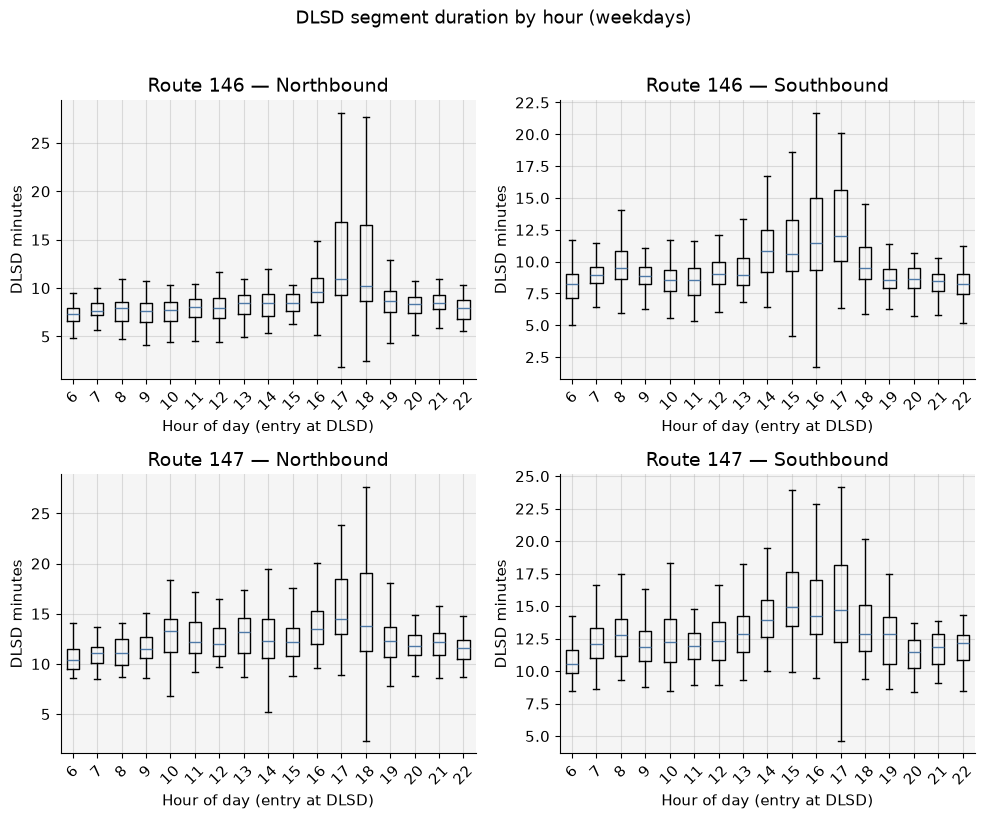

In [9]:
weekday = dlsd_runs.loc[dlsd_runs["is_weekday"]].copy()
directions = sorted(weekday["rtdir"].unique())

fig, axes = plt.subplots(len(ROUTES), len(directions), figsize=(5 * len(directions), 4 * len(ROUTES)), squeeze=False)
for i, route in enumerate(ROUTES):
    for j, rtdir in enumerate(directions):
        ax = axes[i, j]
        sub = weekday[(weekday["route"] == route) & (weekday["rtdir"] == rtdir)]
        if sub.empty:
            ax.set_visible(False)
            continue
        # hours = sorted(sub["hour"].unique())
        hours = list(range(6, 23))  # both routes have multiple scheduled runs in both directions starting at these hours
        data = [sub.loc[sub["hour"] == h, "dlsd_minutes"] for h in hours]
        ax.boxplot(data, tick_labels=hours, showfliers=False)
        ax.set_title(f"Route {route} — {rtdir}")
        ax.set_xlabel("Hour of day (entry at DLSD)")
        ax.set_ylabel("DLSD minutes")
        ax.tick_params(axis="x", rotation=45)
fig.suptitle("DLSD segment duration by hour (weekdays)", y=1.02)
fig.tight_layout()

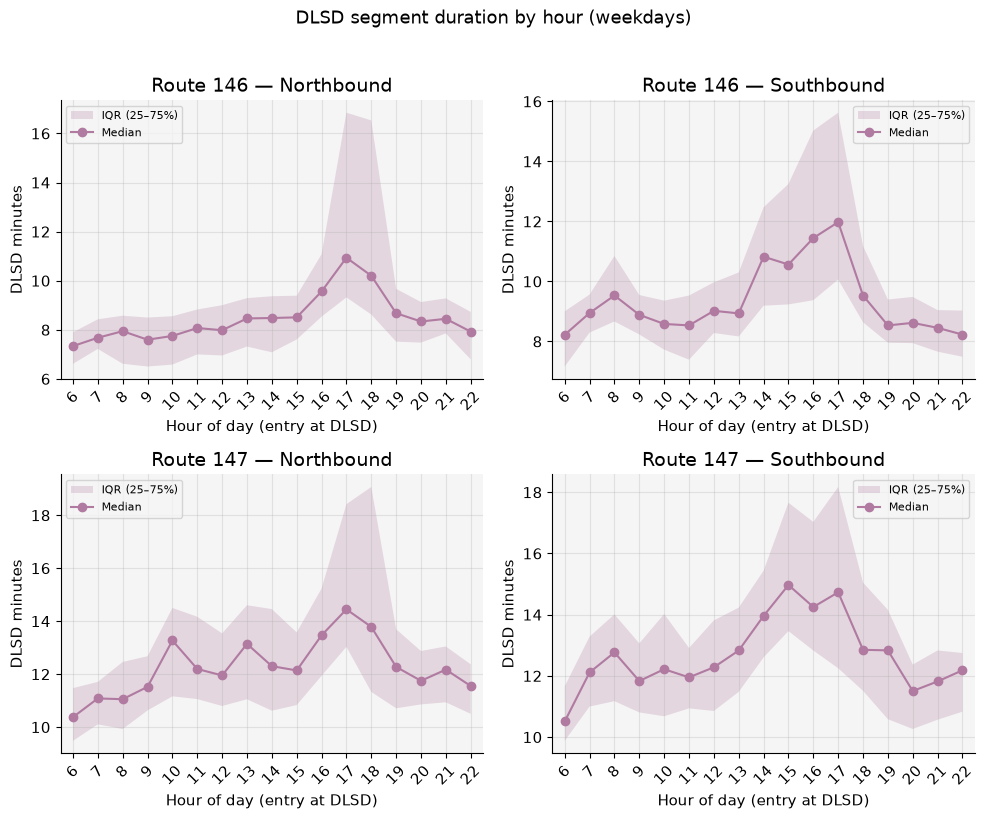

In [10]:
weekday = dlsd_runs.loc[dlsd_runs["is_weekday"]].copy()
directions = sorted(weekday["rtdir"].unique())

fig, axes = plt.subplots(len(ROUTES), len(directions), figsize=(5 * len(directions), 4 * len(ROUTES)), squeeze=False)
for i, route in enumerate(ROUTES):
    for j, rtdir in enumerate(directions):
        ax = axes[i, j]
        sub = weekday[(weekday["route"] == route) & (weekday["rtdir"] == rtdir)]
        if sub.empty:
            ax.set_visible(False)
            continue
        # hours = sorted(sub["hour"].unique())
        hours = list(range(6, 23))

        hour_stats = (
            sub.groupby("hour", as_index=False)["dlsd_minutes"]
            .agg(
                median_min="median",
                q25=lambda s: s.quantile(0.25),
                q75=lambda s: s.quantile(0.75),
                n="count",
            )
        )
        hour_stats = hour_stats.set_index("hour").reindex(hours).reset_index()
        
        x = hour_stats["hour"]
        
        ax.fill_between(
            x,
            hour_stats["q25"],
            hour_stats["q75"],
            alpha=0.25,
            label="IQR (25–75%)",
        )
        ax.plot(
            x,
            hour_stats["median_min"],
            marker="o",
            linestyle="-",
            label="Median",
        )
        ax.set_xticks(hours)
        ax.set_xlim(hours[0] - 0.5, hours[-1] + 0.5)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_title(f"Route {route} — {rtdir}")
        ax.set_xlabel("Hour of day (entry at DLSD)")
        ax.set_ylabel("DLSD minutes")
        ax.tick_params(axis="x", rotation=45)
fig.suptitle("DLSD segment duration by hour (weekdays)", y=1.02)
fig.tight_layout()

In [11]:
def time_period(hour: int) -> str:
    if hour in {23, 0, 1, 2, 3, 4, 5}:
        return "Overnight"
    if 6 <= hour <= 9:
        return "AM Rush"
    if 10 <= hour <= 14:
        return "Midday"
    if 15 <= hour <= 18:
        return "PM Rush"
    return "Evening"


period_order = ["AM Rush", "Midday", "PM Rush", "Evening", "Overnight"]
weekday = dlsd_runs.loc[dlsd_runs["is_weekday"]].copy()
weekday["period"] = weekday["hour"].map(time_period)

period_stats = (
    weekday.groupby(["route", "rtdir", "period"], as_index=False)["dlsd_minutes"]
    .agg(
        median_min="median",
        mean_min="mean",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        n="count",
    )
)
period_stats["period"] = pd.Categorical(period_stats["period"], categories=period_order, ordered=True)
period_stats = period_stats.sort_values(["route", "rtdir", "period"])
display(period_stats)

,route,rtdir,period,median_min,mean_min,q25,q75,n
0,146,Northbound,AM Rush,7.682552,7.769114,6.703993,8.466350,316
2,146,Northbound,Midday,8.098328,8.647259,7.001245,9.061322,525
4,146,Northbound,PM Rush,9.705706,12.937477,8.515453,13.161852,618
1,146,Northbound,Evening,8.424041,8.795448,7.401567,9.243242,551
3,146,Northbound,Overnight,7.991152,8.386676,5.473950,9.163470,159
5,146,Southbound,AM Rush,8.976037,9.391394,8.189652,9.792715,695
7,146,Southbound,Midday,9.025755,10.451484,7.993045,10.242703,598
9,146,Southbound,PM Rush,10.863229,13.081305,9.154445,13.848277,348
6,146,Southbound,Evening,8.468466,8.709098,7.643719,9.165945,293
8,146,Southbound,Overnight,7.112633,7.415481,6.361189,8.382525,68


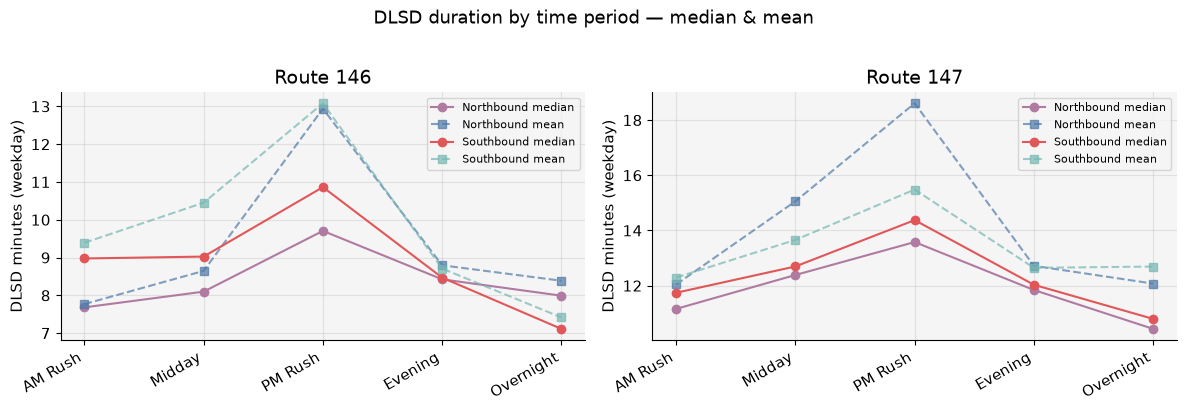

In [12]:
def _period_values(grp: pd.DataFrame, col: str) -> list[float]:
    out: list[float] = []
    for p in period_order:
        row = grp.loc[grp["period"] == p, col]
        out.append(float(row.iloc[0]) if len(row) else np.nan)
    return out


fig, axes = plt.subplots(1, len(ROUTES), figsize=(6 * len(ROUTES), 4), squeeze=False)
for ax, route in zip(axes.ravel(), ROUTES):
    sub = period_stats[period_stats["route"] == route]
    for rtdir, grp in sub.groupby("rtdir"):
        grp = grp.sort_values("period")
        x = np.arange(len(period_order))
        med = _period_values(grp, "median_min")
        mn = _period_values(grp, "mean_min")
        ax.plot(x, med, marker="o", label=f"{rtdir} median", linestyle="-")
        ax.plot(x, mn, marker="s", label=f"{rtdir} mean", linestyle="--", alpha=0.7)
    ax.set_xticks(range(len(period_order)))
    ax.set_xticklabels(period_order, rotation=30, ha="right")
    ax.set_ylabel("DLSD minutes (weekday)")
    ax.set_title(f"Route {route}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle("DLSD duration by time period — median & mean", y=1.02)
fig.tight_layout()
plt.show()

## 5. Speed on DLSD

`implied_dlsd_mph` = hop distance / `dlsd_minutes` (not Mansueto ping-interval `speed_mph`). See [mansueto_imputation_investigation.ipynb](mansueto_imputation_investigation.ipynb).

In [13]:
# implied_dlsd_mph from build_dlsd_runs; refresh segment distance from boundaries if needed

def segment_feet(pid: str) -> float:
    info = dlsd_boundaries[str(pid)]
    pdist = info.get("pdist_gap_ft")
    if pdist is not None and not (isinstance(pdist, float) and np.isnan(pdist)):
        return float(pdist)
    return float(info["hop_feet"])


dlsd_runs["dlsd_feet"] = dlsd_runs["pid"].map(segment_feet)
dlsd_runs["dlsd_miles"] = dlsd_runs["dlsd_feet"] / 5280
dlsd_runs["implied_dlsd_mph"] = dlsd_runs["dlsd_miles"] / (dlsd_runs["dlsd_minutes"] / 60)

dlsd_runs[["route", "rtdir", "dlsd_minutes", "dlsd_miles", "implied_dlsd_mph"]].describe()

,dlsd_minutes,dlsd_miles,implied_dlsd_mph
count,10952.000000,10952.000000,10952.000000
mean,12.081067,4.334336,27.378645
std,10.566627,1.323665,29.902676
min,0.323740,3.026326,0.976883
25%,8.569415,3.026326,19.894899
50%,10.355426,3.103220,24.124044
75%,12.924394,5.661553,29.275555
max,354.187883,5.766667,1049.276566


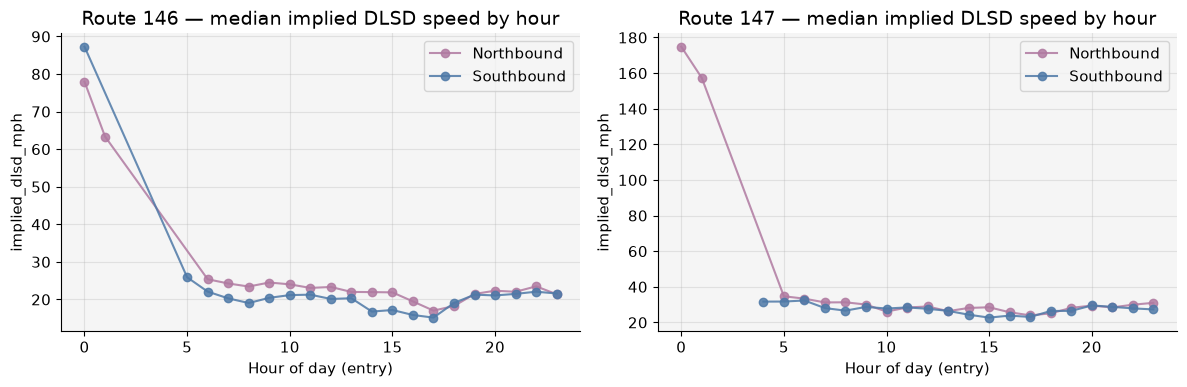

In [14]:
weekday = dlsd_runs.loc[dlsd_runs["is_weekday"]].copy()
speed_by_hour = (
    weekday.groupby(["route", "rtdir", "hour"], as_index=False)["implied_dlsd_mph"].median()
)

fig, axes = plt.subplots(1, len(ROUTES), figsize=(6 * len(ROUTES), 4), squeeze=False)
for ax, route in zip(axes.ravel(), ROUTES):
    sub = speed_by_hour[speed_by_hour["route"] == route]
    for rtdir, grp in sub.groupby("rtdir"):
        grp = grp.sort_values("hour")
        ax.plot(
            grp["hour"],
            grp["implied_dlsd_mph"],
            marker="o",
            label=rtdir,
            alpha=0.85,
        )
    ax.set_title(f"Route {route} — median implied DLSD speed by hour")
    ax.set_xlabel("Hour of day (entry)")
    ax.set_ylabel("implied_dlsd_mph")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

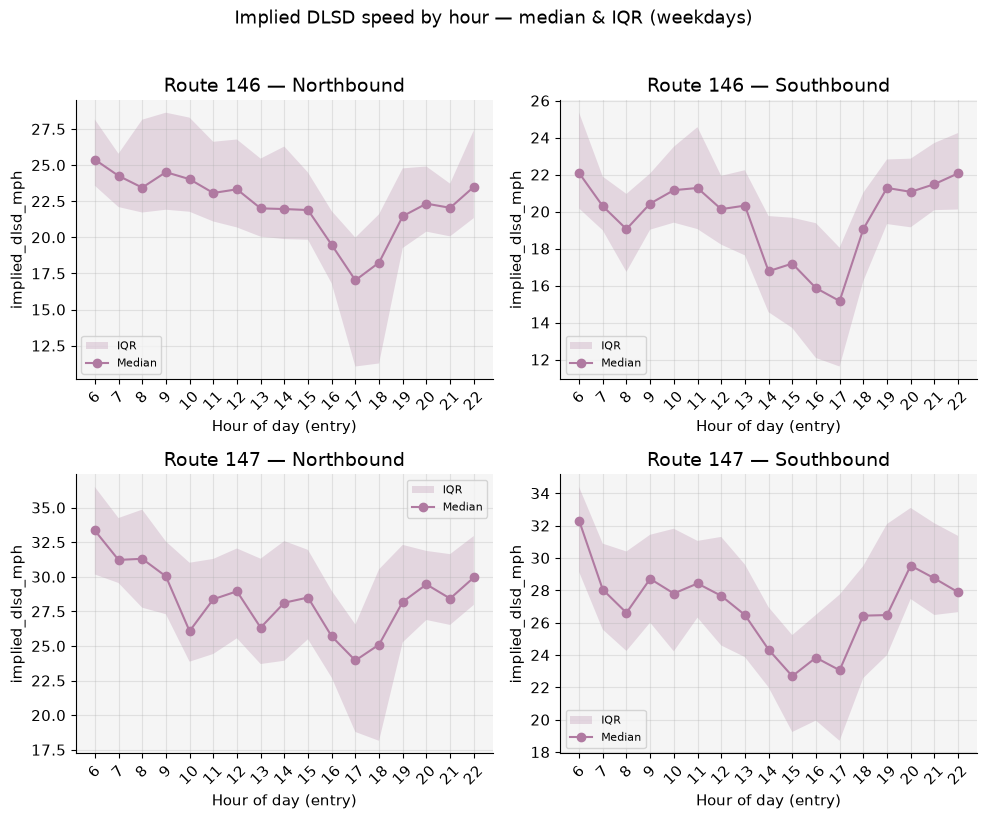

In [15]:
weekday = dlsd_runs.loc[dlsd_runs["is_weekday"]].copy()
directions = sorted(weekday["rtdir"].unique())
hours = list(range(6, 23))

fig, axes = plt.subplots(
    len(ROUTES), len(directions),
    figsize=(5 * len(directions), 4 * len(ROUTES)),
    squeeze=False,
)
for i, route in enumerate(ROUTES):
    for j, rtdir in enumerate(directions):
        ax = axes[i, j]
        sub = weekday[(weekday["route"] == route) & (weekday["rtdir"] == rtdir)]
        if sub.empty:
            ax.set_visible(False)
            continue

        hour_stats = (
            sub.groupby("hour", as_index=False)["implied_dlsd_mph"]
            .agg(
                median_mph="median",
                q25=lambda s: s.quantile(0.25),
                q75=lambda s: s.quantile(0.75),
                n="count",
            )
        )
        hour_stats = hour_stats.set_index("hour").reindex(hours).reset_index()

        x = hour_stats["hour"]
        ax.fill_between(x, hour_stats["q25"], hour_stats["q75"], alpha=0.25, label="IQR")
        ax.plot(x, hour_stats["median_mph"], marker="o", linestyle="-", label="Median")
        ax.set_title(f"Route {route} — {rtdir}")
        ax.set_xlabel("Hour of day (entry)")
        ax.set_ylabel("implied_dlsd_mph")
        ax.set_xticks(hours)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle("Implied DLSD speed by hour — median & IQR (weekdays)", y=1.02)
fig.tight_layout()
plt.show()

## 6. Summary

Run the cell below after §3–5 for computed medians. Fill in narrative once you have reviewed the charts.

In [16]:
weekday = dlsd_runs.loc[dlsd_runs["is_weekday"]]
weekend = dlsd_runs.loc[~dlsd_runs["is_weekday"]]


def med(sub, route):
    return float(sub.loc[sub["route"] == route, "dlsd_minutes"].median())


print("=== Weekday vs weekend (median dlsd_minutes) ===")
for route in ROUTES:
    wkd = med(weekday, route)
    wend = med(weekend, route)
    print(f"  route {route}: weekday {wkd:.1f} min, weekend {wend:.1f} min")

print("\n=== Weekday median implied_dlsd_mph by route ===")
for route in ROUTES:
    wk = weekday[weekday["route"] == route]
    spd = wk["implied_dlsd_mph"].median()
    print(f"  route {route}: {spd:.1f} mph")

print("\nDraft bullets:")
print("- DLSD duration filtered with analysis_ok (structural), not [1,120] minutes.")
print("- Mansueto imputation ~5 min resolution; see mansueto_imputation_investigation.ipynb.")
print("- implied_dlsd_mph is hop distance / dlsd_minutes (not Mansueto speed_mph column).")

=== Weekday vs weekend (median dlsd_minutes) ===
  route 146: weekday 8.7 min, weekend 8.8 min
  route 147: weekday 12.3 min, weekend 12.0 min

=== Weekday median implied_dlsd_mph by route ===
  route 146: 21.0 mph
  route 147: 27.9 mph

Draft bullets:
- DLSD duration filtered with analysis_ok (structural), not [1,120] minutes.
- Mansueto imputation ~5 min resolution; see mansueto_imputation_investigation.ipynb.
- implied_dlsd_mph is hop distance / dlsd_minutes (not Mansueto speed_mph column).
